In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
from sklearn.metrics import r2_score
import os

print("Cell 1: Memuat seluruh dataset eksperimen dari Excel...")

MW = {
    'nhs_myr': 325.449, 'desb30': 5706.524, 'detemir': 5916.885, 'nhs': 115.088,
    'A1': 5916.885, 'A1_B1': 6127.246, 'A1_B29': 6127.246, 'B1_B29': 6127.246, # semua single myristoylated (A1-, B1-, dan detemir memiliki MW yang sama). semua double myristoylated memiliki MW yang sama
    'A1_B29_B1': 6337.607, 'B1': 5916.885
}

# 8 Komponen utama kromatogram Anda
species_list = ['desb30', 'A1', 'detemir', 'A1_B29', 'B1_B29', 'A1_B29_B1', 'A1_B1', 'B1']

excel_filename = 'data_kinetika.xlsx'
if not os.path.exists(excel_filename):
    raise FileNotFoundError(f"File '{excel_filename}' tidak ditemukan di folder!")

df = pd.read_excel(excel_filename, sheet_name='data')
df['Peak Identification'] = df['Peak Identification'].astype(str).str.strip()
df['Waktu Sampling'] = df['Waktu Sampling'].astype(str).str.strip()

time_exp = np.array([0, 10, 30, 60, 90, 120])
unique_t_strings = sorted(df['Waktu Sampling'].unique(), key=lambda x: int(''.join(filter(str.isdigit, x))) if any(c.isdigit() for c in x) else 0)
time_map = {t_str: time_exp[i] if i < len(time_exp) else time_exp[-1] for i, t_str in enumerate(unique_t_strings)}
df['Time_Min'] = df['Waktu Sampling'].map(time_map)

experimental_dataset = {}
ratios = [1.0, 1.5, 2.0]

for r in ratios:
    df_ratio = df[df['Perbandingan'] == r]
    experimental_dataset[r] = {}
    for sp in species_list:
        sub_df = df_ratio[df_ratio['Peak Identification'] == sp]
        means_gL = []
        for t in time_exp:
            val = sub_df[sub_df['Time_Min'] == t]['Conc'].mean()
            means_gL.append(val if not np.isnan(val) else 0.0)
        experimental_dataset[r][sp] = np.array(means_gL) / MW[sp]

print("Cell 1 Selesai: Data siap diproses.")

Cell 1: Memuat seluruh dataset eksperimen dari Excel...
Cell 1 Selesai: Data siap diproses.


In [2]:
class FinalKineticModel:
    def __init__(self, params):
        self.k = params[:7]
        self.n = params[7]
        self.m = params[8]
        
        self.species = ['nhs_myr', 'desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']
        self.idx = {name: i for i, name in enumerate(self.species)}

    def _ode_system(self, t, y):
        y_clip = np.maximum(y, 0) # Mencegah nilai negatif akibat step solver
        idx = self.idx
        C_nhsm = y_clip[idx['nhs_myr']]
        
        r1 = self.k[0] * (C_nhsm**self.n) * (y_clip[idx['desb30']]**self.m)
        r2 = self.k[1] * (C_nhsm**self.n) * (y_clip[idx['desb30']]**self.m)
        r3 = self.k[2] * (C_nhsm**self.n) * (y_clip[idx['desb30']]**self.m)
        
        r4 = self.k[3] * (C_nhsm**self.n) * (y_clip[idx['A1']]**self.m)
        r5 = self.k[4] * (C_nhsm**self.n) * (y_clip[idx['A1']]**self.m)
        
        r6 = self.k[5] * (C_nhsm**self.n) * (y_clip[idx['detemir']]**self.m)
        r7 = self.k[6] * (C_nhsm**self.n) * (y_clip[idx['A1_B29']]**self.m)
        
        dydt = np.zeros_like(y)
        
        dydt[idx['nhs_myr']] = -(r1 + r2 + r3 + r4 + r5 + r6 + r7)
        dydt[idx['desb30']]  = -(r1 + r2 + r3)
        dydt[idx['A1']]      = r1 - (r4 + r5)
        dydt[idx['B1']]      = r2
        dydt[idx['detemir']] = r3 - r6
        
        dydt[idx['A1_B1']]   = r4
        dydt[idx['A1_B29']]  = r5 - r7
        dydt[idx['B1_B29']]  = r6
        dydt[idx['A1_B29_B1']] = r7
        
        return dydt

    def simulate(self, y0, t_span, t_eval):
        # PERBAIKAN: Menggunakan 'RK45' untuk menghindari kalkulasi Jacobian numerik yang sensitif
        return solve_ivp(self._ode_system, t_span, y0, t_eval=t_eval, method='RK45')

print("Cell 2 Selesai: Model ODE berbasis RK45 yang stabil telah siap.")

Cell 2 Selesai: Model ODE berbasis RK45 yang stabil telah siap.


In [4]:
nhs_myr_base_molL = 0.4427802248 / MW['nhs_myr'] # C_t=0 NHS_myr memiliki nilai konsentrasi yang berbeda-beda tergantung perbandingan mol eksperimen pada hari tersebut.

def objective_function_global(log_params):
    k_vals = np.exp(log_params[:7])
    n, m = log_params[7], log_params[8]
    full_params = list(k_vals) + [n, m]
    
    total_sse_gL = 0
    ratios = [1.0, 1.5, 2.0]
    
    for r in ratios:
        y0 = np.zeros(9)
        y0[0] = nhs_myr_base_molL * r
        for i, sp in enumerate(['desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']):
            y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0
            
        model = FinalKineticModel(full_params)
        sol = model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)
        
        if sol.status != 0 or np.isnan(sol.y).any(): 
            return 1e10
        
        mapping_idx = {
            'desb30': 1, 'A1': 2, 'B1': 3, 'detemir': 4, 
            'A1_B1': 5, 'A1_B29': 6, 'B1_B29': 7, 'A1_B29_B1': 8
        }
        
        for sp in species_list:
            ode_pos = mapping_idx[sp]
            sim_gL = sol.y[ode_pos] * MW[sp]
            exp_gL = experimental_dataset[r][sp] * MW[sp]
            total_sse_gL += np.sum((sim_gL - exp_gL)**2)
            
    return total_sse_gL

# PERBAIKAN: Mengunci batas bawah orde n dan m minimal 1.0 (mencegah pembagian dengan nol)
bounds = [(np.log(1e-4), np.log(1e4))] * 7 + [(1.0, 2.5), (1.0, 2.5)]

print("Memulai Pencarian Parameter Global yang Baru...")
# Proses running sekarang akan berjalan jauh lebih ringan dan cepat
result = differential_evolution(
    objective_function_global, 
    bounds, 
    popsize=10, 
    maxiter=35, 
    seed=42
)
print("Cell 3 Selesai: Parameter Global Berhasil Dikunci Tanpa Error!")

Memulai Pencarian Parameter Global yang Baru...
Cell 3 Selesai: Parameter Global Berhasil Dikunci Tanpa Error!


In [5]:
opt_k = np.exp(result.x[:7])
opt_orders = result.x[7:]
final_params = list(opt_k) + list(opt_orders)

print("\n================== HASIL KINETIKA MEKANISTIK GLOBAL ==================")
pathway_names = [
    'k1 (DesB30 -> A1)      ', 'k2 (DesB30 -> B1)      ', 'k3 (DesB30 -> Detemir) ',
    'k4 (A1 -> A1_B1)       ', 'k5 (A1 -> A1_B29)      ', 'k6 (Detemir -> B1_B29) ',
    'k7 (A1_B29 -> Tri)     '
]
for name, val in zip(pathway_names, opt_k):
    print(f"  {name}: {val:.4e}")
print(f"  Order 'n' (NHS-myr)         : {opt_orders[0]:.3f}")
print(f"  Order 'm' (Substrat Insulin): {opt_orders[1]:.3f}")
print(f"  Final Minimum SSE (g/L)     : {result.fun:.5f}")
print("======================================================================\n")

print("=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===")
for r in ratios:
    y0 = np.zeros(9)
    y0[0] = nhs_myr_base_molL * r
    for i, sp in enumerate(['desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']):
        y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0
        
    model = FinalKineticModel(final_params)
    sol = model.simulate(y0, (0, 120), time_exp)
    
    desb30_0 = y0[1] * MW['desb30']
    desb30_akhir = sol.y[1][-1] * MW['desb30']
    detemir_akhir = sol.y[4][-1] * MW['detemir']
    
    konversi = ((desb30_0 - desb30_akhir) / desb30_0) * 100 if desb30_0 > 0 else 0
    yield_detemir = (detemir_akhir / desb30_0) * 100 if desb30_0 > 0 else 0
    
    print(f"Rasio Skenario 1 : {r}")
    print(f"  -> Konversi Massa DesB30 : {konversi:.2f}%")
    print(f"  -> Yield Hasil Detemir    : {yield_detemir:.2f}%")


================== HASIL KINETIKA MEKANISTIK GLOBAL ==================
  k1 (DesB30 -> A1)      : 1.8114e+03
  k2 (DesB30 -> B1)      : 2.4461e+02
  k3 (DesB30 -> Detemir) : 6.8156e+03
  k4 (A1 -> A1_B1)       : 1.8406e+03
  k5 (A1 -> A1_B29)      : 1.0000e+04
  k6 (Detemir -> B1_B29) : 9.6557e+01
  k7 (A1_B29 -> Tri)     : 6.4995e+02
  Order 'n' (NHS-myr)         : 1.000
  Order 'm' (Substrat Insulin): 1.561
  Final Minimum SSE (g/L)     : 0.26850

=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===
Rasio Skenario 1 : 1.0
  -> Konversi Massa DesB30 : 96.76%
  -> Yield Hasil Detemir    : 70.99%
Rasio Skenario 1 : 1.5
  -> Konversi Massa DesB30 : 95.78%
  -> Yield Hasil Detemir    : 70.26%
Rasio Skenario 1 : 2.0
  -> Konversi Massa DesB30 : 97.12%
  -> Yield Hasil Detemir    : 69.53%


=== ANALISIS ERROR PER SKENARIO RASIO ===
Rasio 1 : 1.0 -> RMSE = 0.0586 g/L
Rasio 1 : 1.5 -> RMSE = 0.0416 g/L
Rasio 1 : 2.0 -> RMSE = 0.0207 g/L


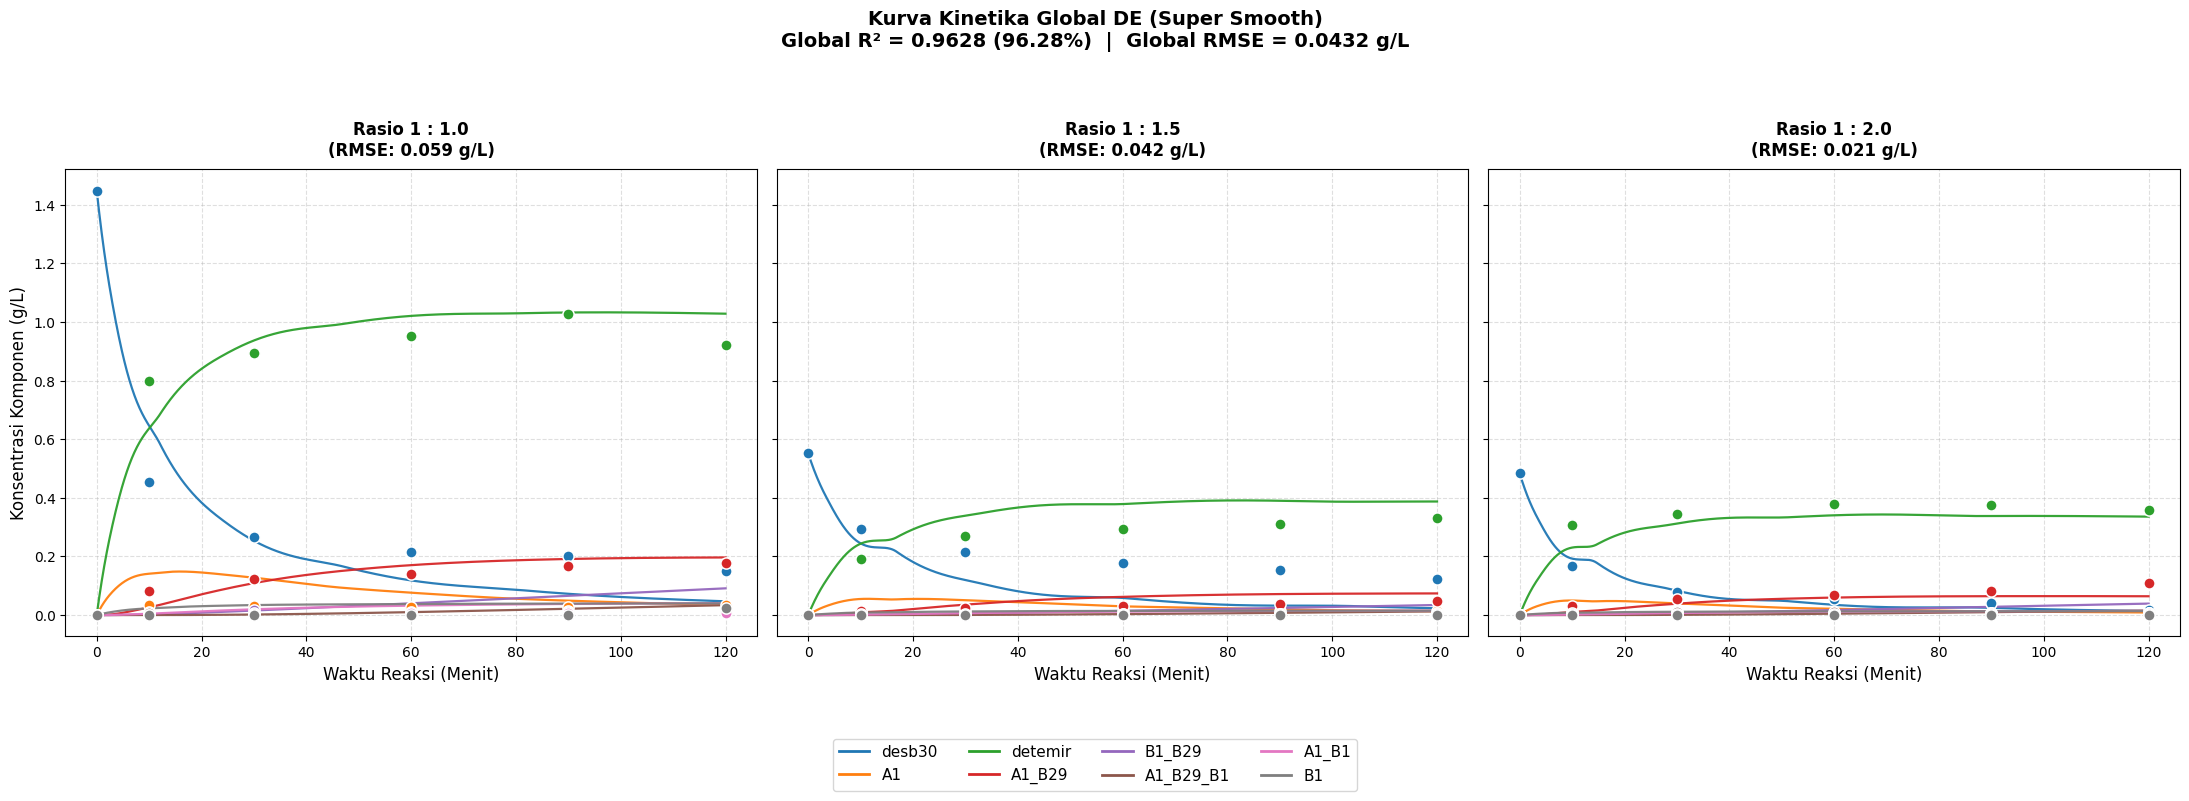


==================== RINGKASAN PERFORMA MODEL ====================
 >> Akurasi Tren (Global R²) : 0.9628 (96.28%)
 >> Deviasi Rata-rata (Global RMSE) : 0.0432 g/L


In [10]:
from sklearn.metrics import mean_squared_error

y_true_global, y_pred_global = [], []

plot_colors = {
    'desb30': '#1f77b4', 'A1': '#ff7f0e', 'detemir': '#2ca02c', 
    'A1_B29': '#d62728', 'B1_B29': '#9467bd', 'A1_B29_B1': '#8c564b', 
    'A1_B1': '#e377c2', 'B1': '#7f7f7f'
}

time_smooth = np.linspace(0, 120, 1000)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True)

print("=== ANALISIS ERROR PER SKENARIO RASIO ===")

for idx, r in enumerate(ratios):
    y0 = np.zeros(9)
    y0[0] = nhs_myr_base_molL * r
    for i, sp in enumerate(['desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']):
        y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0
        
    model = FinalKineticModel(final_params)
    sol_smooth = model.simulate(y0, (0, 120), time_smooth)
    sol_exp = model.simulate(y0, (0, 120), time_exp)
    
    y_true_ratio, y_pred_ratio = [], []
    
    mapping_idx = {
        'desb30': 1, 'A1': 2, 'B1': 3, 'detemir': 4, 
        'A1_B1': 5, 'A1_B29': 6, 'B1_B29': 7, 'A1_B29_B1': 8
    }
    
    for sp in species_list:
        ode_pos = mapping_idx[sp]
        sim_gL_smooth = sol_smooth.y[ode_pos] * MW[sp]
        sim_gL_exp = sol_exp.y[ode_pos] * MW[sp]
        exp_gL = experimental_dataset[r][sp] * MW[sp]
        
        # Simpan untuk evaluasi rasio & global
        y_true_ratio.extend(exp_gL)
        y_pred_ratio.extend(sim_gL_exp)
        y_true_global.extend(exp_gL)
        y_pred_global.extend(sim_gL_exp)
        
        axes[idx].plot(time_smooth, sim_gL_smooth, color=plot_colors[sp], linewidth=1.6, alpha=0.95)
        axes[idx].scatter(time_exp, exp_gL, color=plot_colors[sp], edgecolors='white', linewidth=1.1, s=65, zorder=5)

    # Hitung RMSE khusus untuk rasio ini
    rmse_ratio = np.sqrt(mean_squared_error(y_true_ratio, y_pred_ratio))
    print(f"Rasio 1 : {r:.1f} -> RMSE = {rmse_ratio:.4f} g/L")
    
    ax = axes[idx]
    ax.set_title(f"Rasio 1 : {r:.1f}\n(RMSE: {rmse_ratio:.3f} g/L)", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Waktu Reaksi (Menit)", fontsize=12)
    if idx == 0:
        ax.set_ylabel("Konsentrasi Komponen (g/L)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)

# Hitung Statistik Global Akhir
global_r2 = r2_score(y_true_global, y_pred_global)
global_rmse = np.sqrt(mean_squared_error(y_true_global, y_pred_global))

# Penataan Legend & Title
handles, labels = axes[0].get_legend_handles_labels()
# Mengambil label unik tiruan untuk memunculkan legenda kromatogram tanpa tulisan "(Model)" berulang
dummy_handles = [plt.Line2D([0], [0], color=plot_colors[sp], lw=2) for sp in species_list]
fig.legend(dummy_handles, species_list, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=11, frameon=True)

plt.suptitle(f"Kurva Kinetika Global DE (Super Smooth)\nGlobal R² = {global_r2:.4f} ({global_r2*100:.2f}%)  |  Global RMSE = {global_rmse:.4f} g/L", 
             fontsize=14, fontweight='bold', y=1.06)

plt.tight_layout()
plt.show()

print("\n==================== RINGKASAN PERFORMA MODEL ====================")
print(f" >> Akurasi Tren (Global R²) : {global_r2:.4f} ({global_r2*100:.2f}%)")
print(f" >> Deviasi Rata-rata (Global RMSE) : {global_rmse:.4f} g/L")
print("==================================================================")

In [8]:
my_final_model = ExpandedKineticModel(final_params_full)
model_file_path = 'multi_ratio_kinetic_optimized_model.dill'

with open(model_file_path, 'wb') as f:
    dill.dump(my_final_model, f)
print(f"\nKinetic MODEL Multi-Rasio sukses disimpan ke '{model_file_path}'!")


Kinetic MODEL Multi-Rasio sukses disimpan ke 'multi_ratio_kinetic_optimized_model.dill'!
